In [67]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import torch as tch
import torch.nn as nn

tch.cuda.is_available()
data = pd.read_csv('adult.csv')


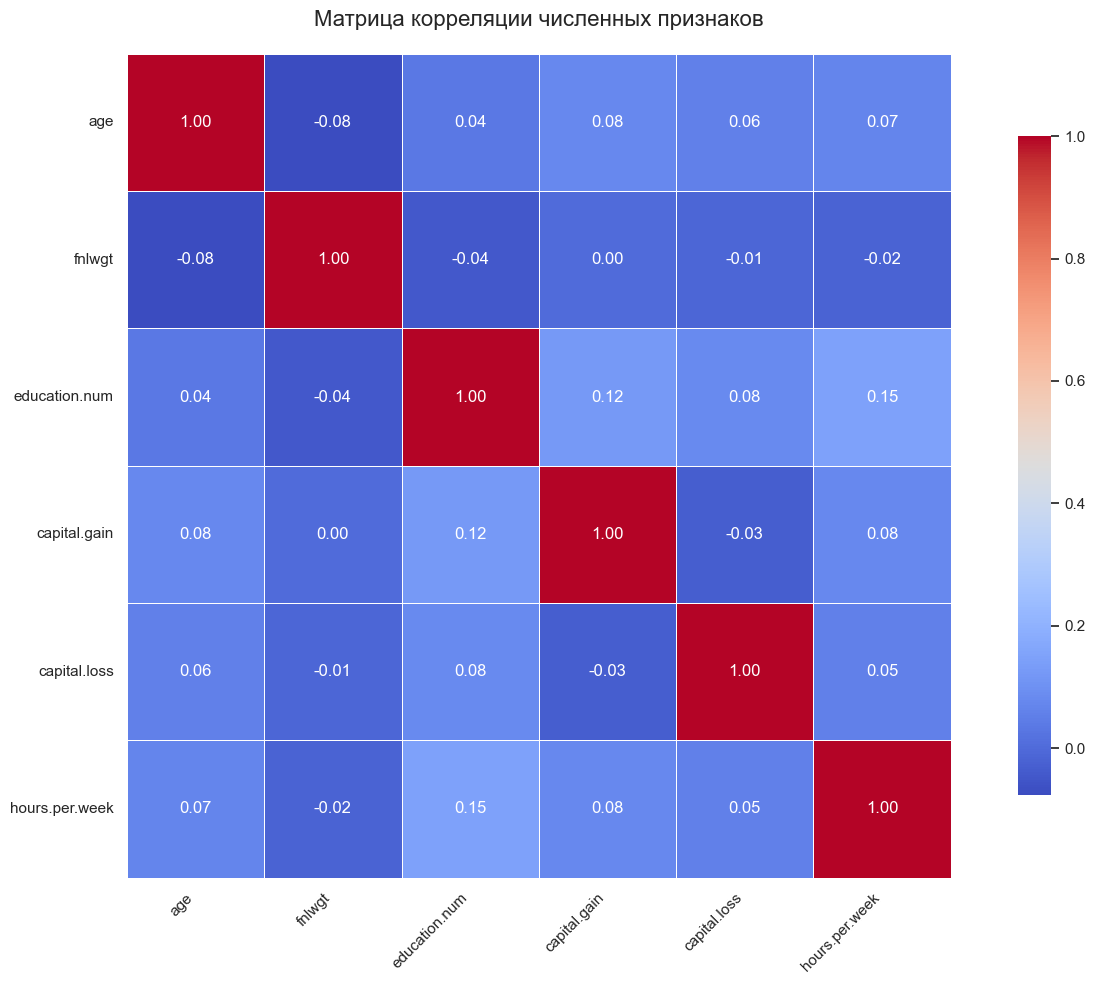

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns


numeric_data = data.select_dtypes(include=[np.number])

corr_matrix = numeric_data.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm',  # Синий (отрицательная) -> Белый (0) -> Красный (положительная)
    square=True,      # Ячейки квадратные
    linewidths=0.5,   # Линии между ячейками
    cbar_kws={"shrink": 0.8} # Размер цветной шкалы справа
)

plt.title('Матрица корреляции численных признаков', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right') # Поворот подписей для читаемости
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [69]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


data = data.drop(["education"],axis=1)  # уже есть колонка с его численным значением
data['sex'] = data['sex'].map({'Female': 0, 'Male': 1})
data['income'] = data['income'].map({'<=50K': 0, '>50K': 1})
work_map = {"Without-pay":"Without-pay", "Never-worked":"Without-pay"}
data["workclass"] = data["workclass"].map(work_map)

data = pd.get_dummies(data, columns=['workclass'], dtype=int)
data = pd.get_dummies(data, columns=['marital.status'], dtype=int)
data = pd.get_dummies(data, columns=['occupation'], dtype=int)
data = pd.get_dummies(data, columns=['relationship'], dtype=int)
data = pd.get_dummies(data, columns=['race'], dtype=int)

top_countries = [
    'United-States', 'Mexico', '?', 'Philippines', 'Germany', 
    'Canada', 'Puerto-Rico', 'El-Salvador',
]
def map_to_group(value, allowed_list):
    if value in allowed_list:
        return value
    else:
        return 'Other'
data['native.country'] = data['native.country'].apply(lambda x: map_to_group(x, top_countries))
data = pd.get_dummies(data, columns=['native.country'], dtype=int)

y = data['income']
X = data.drop('income', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Найдено числовых колонок: 51. Начинаем построение...



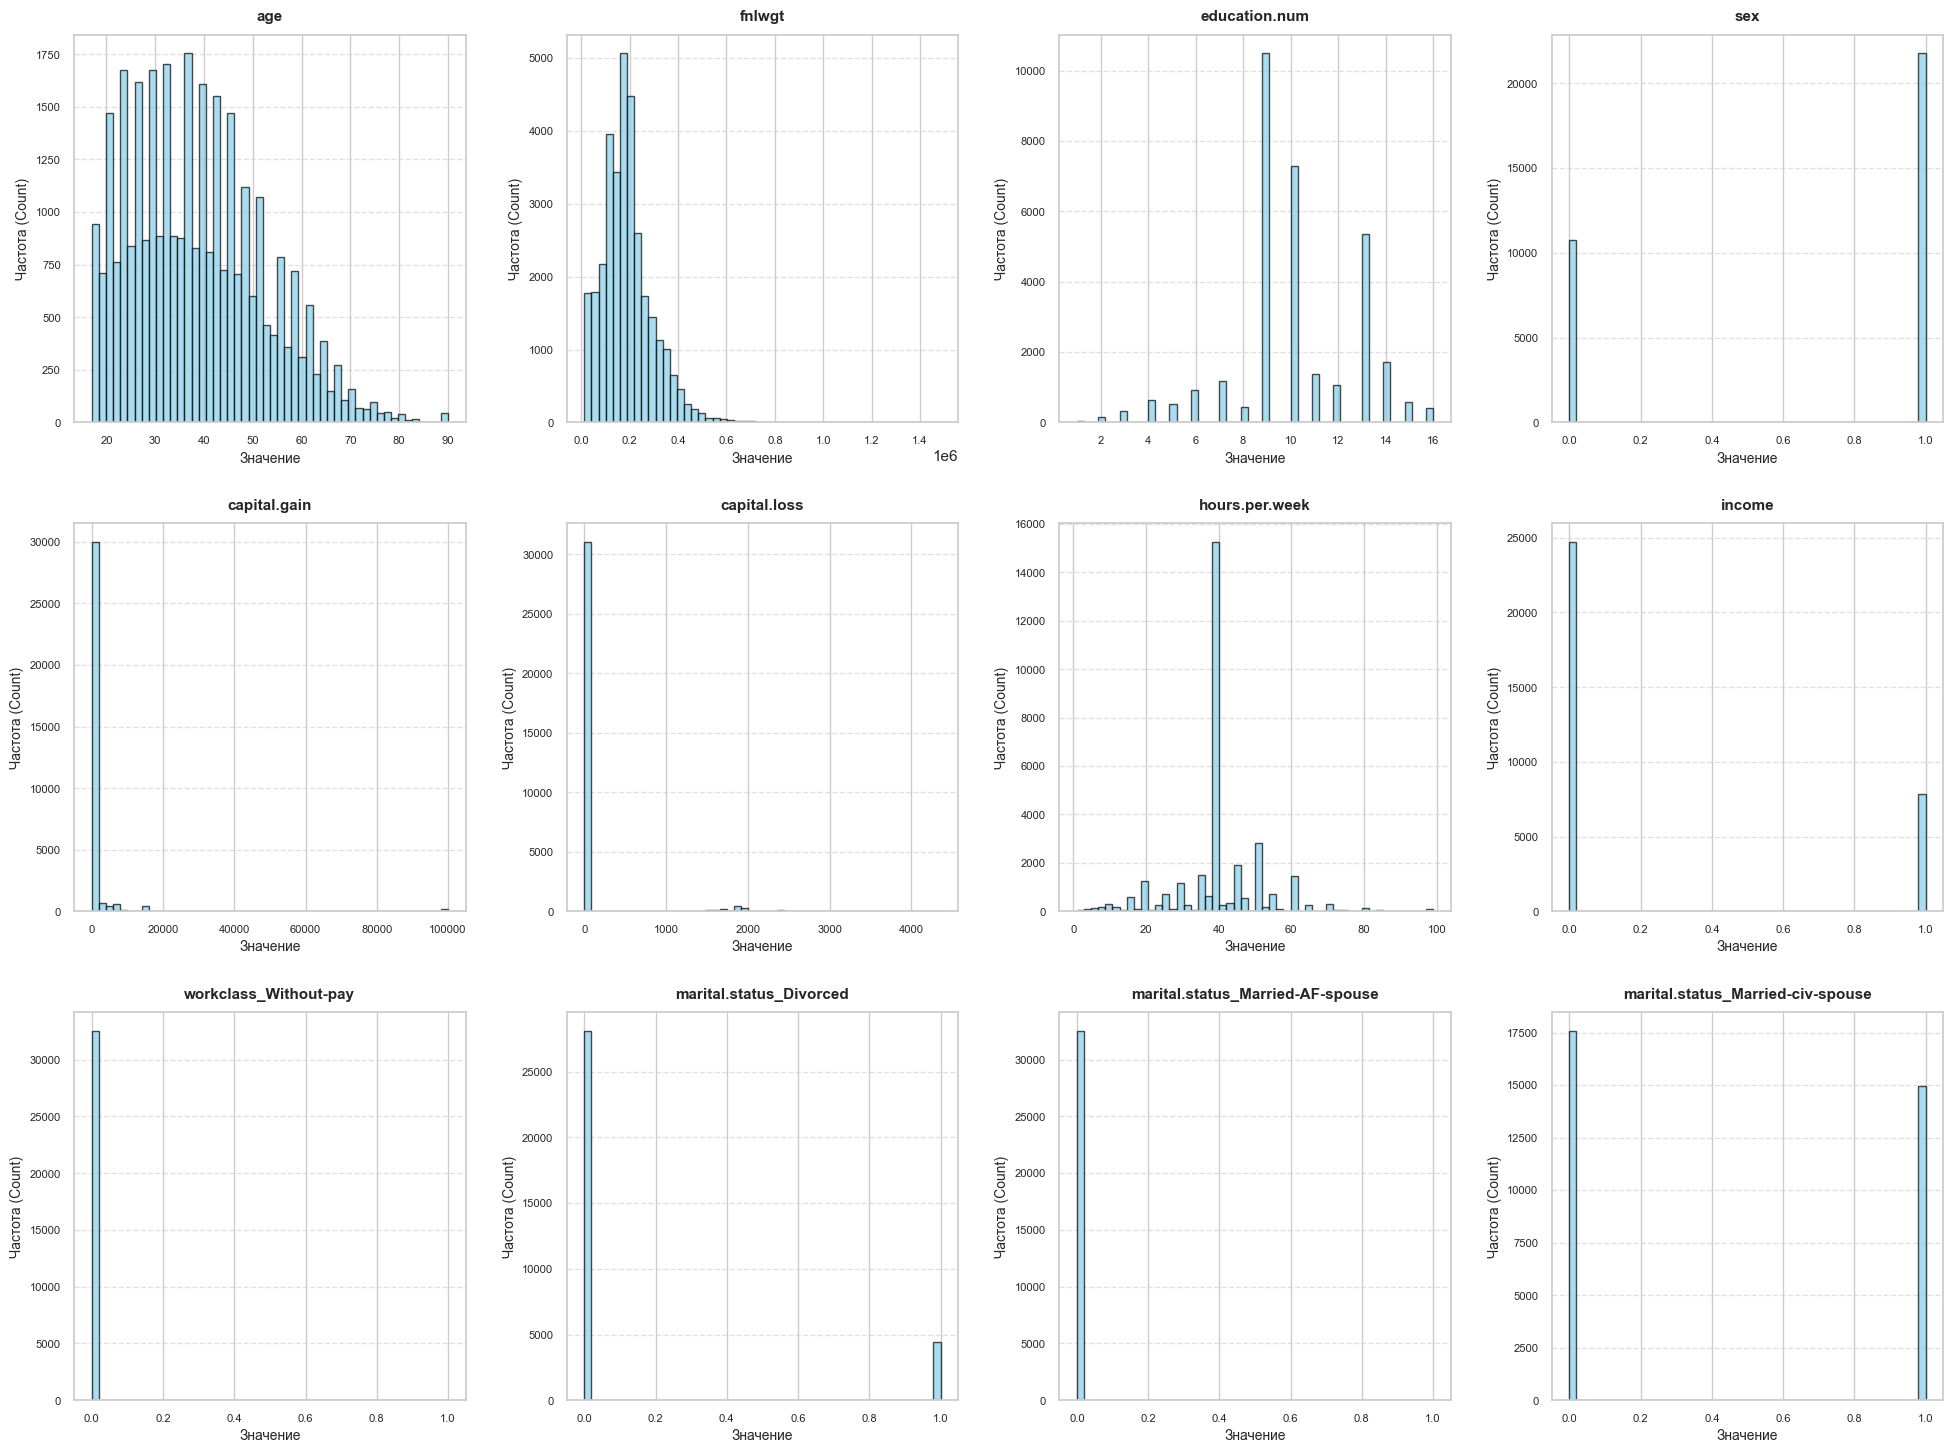

--- Отображена фигура 1 из 5 ---



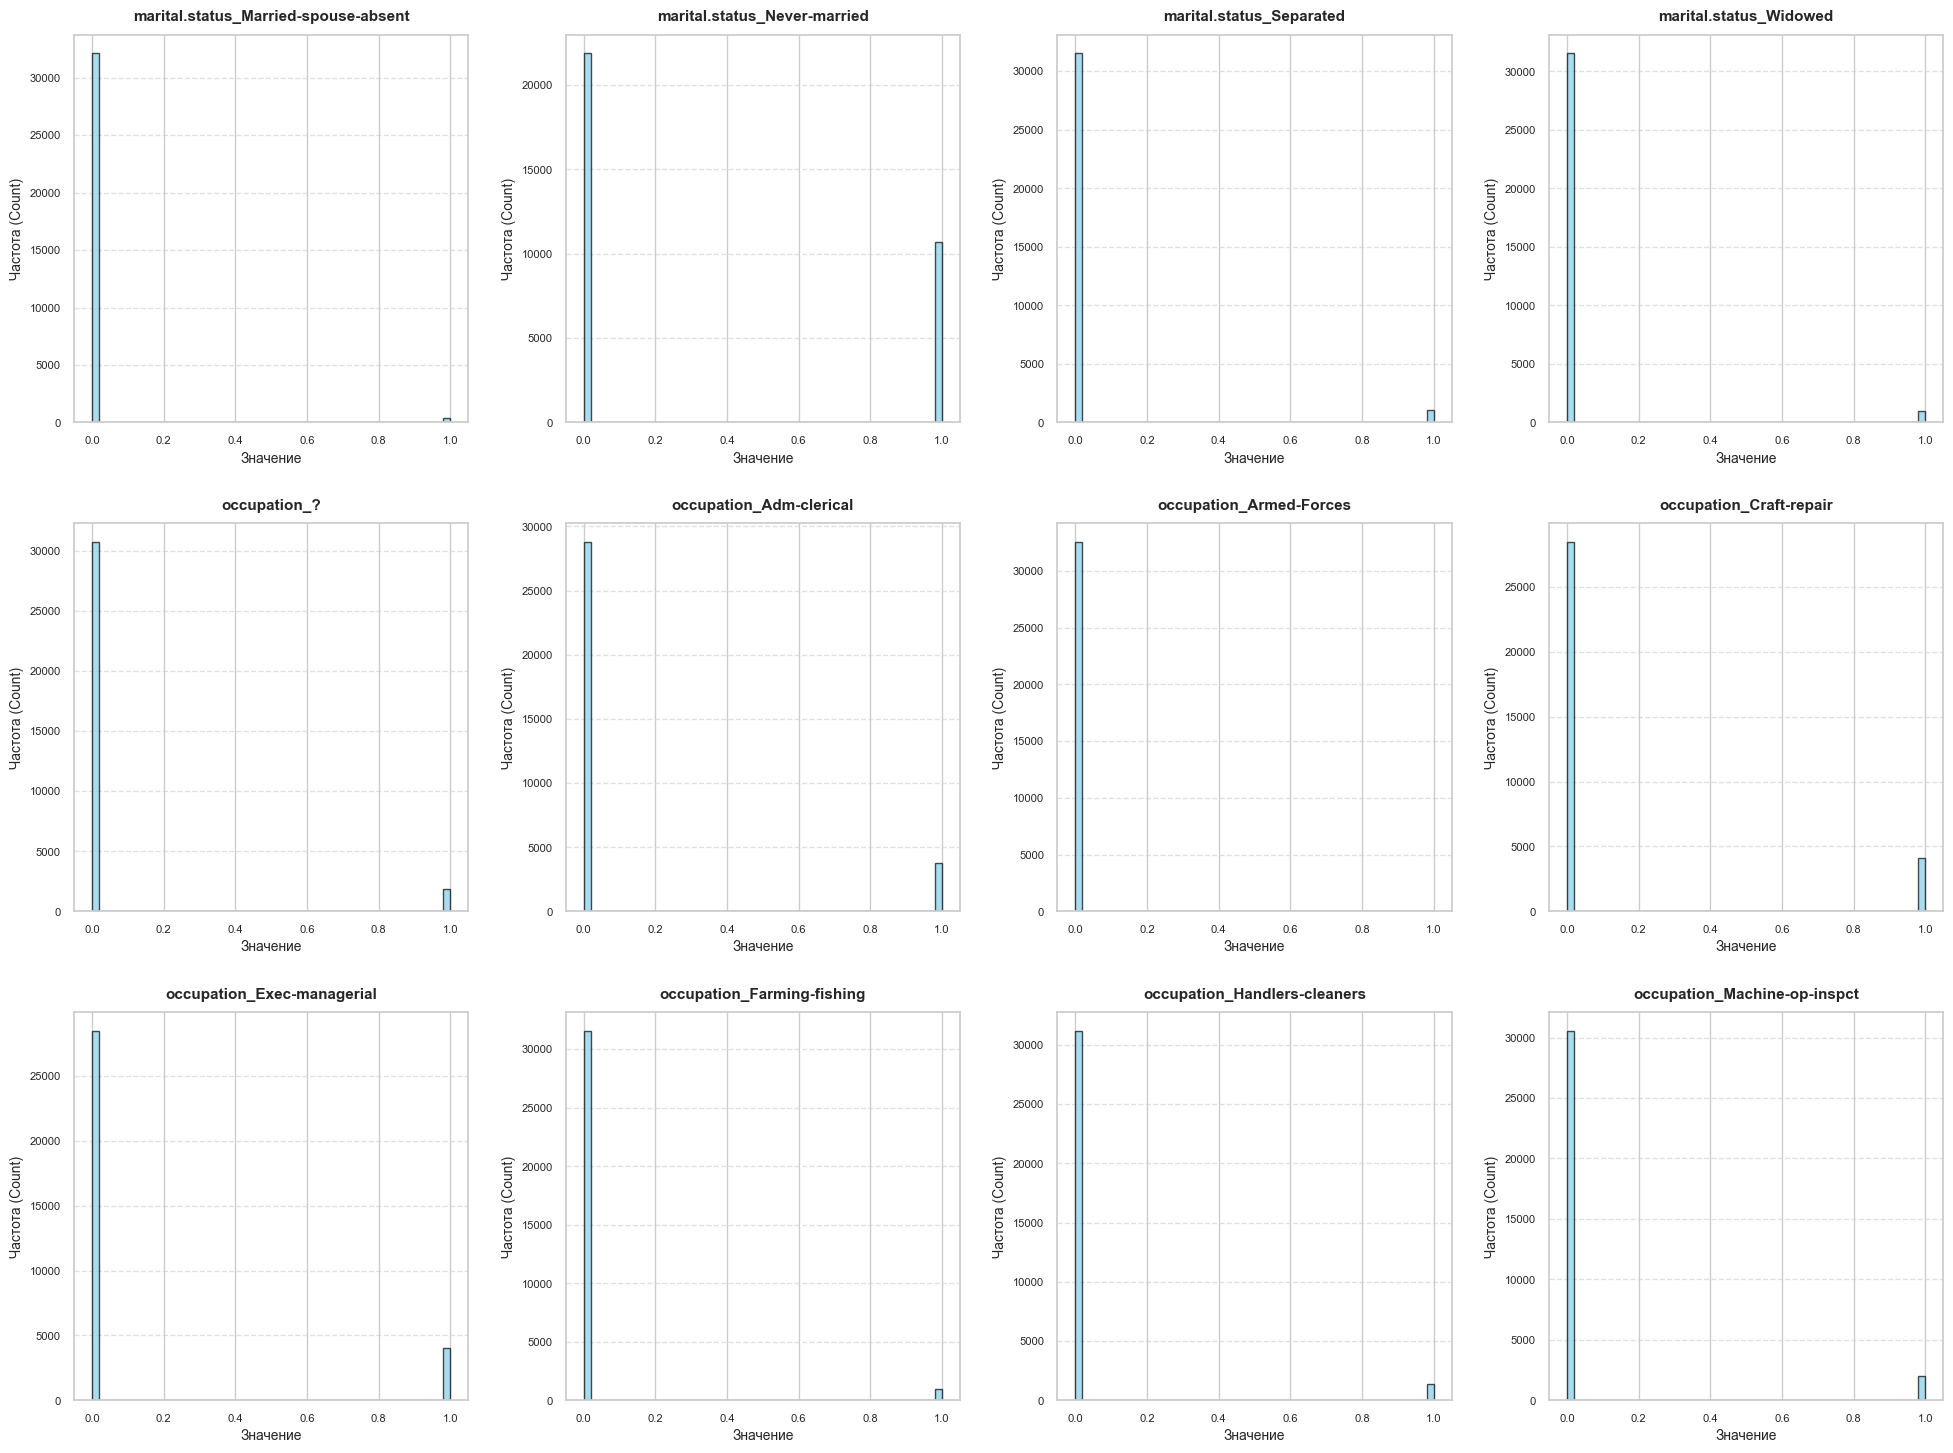

--- Отображена фигура 2 из 5 ---



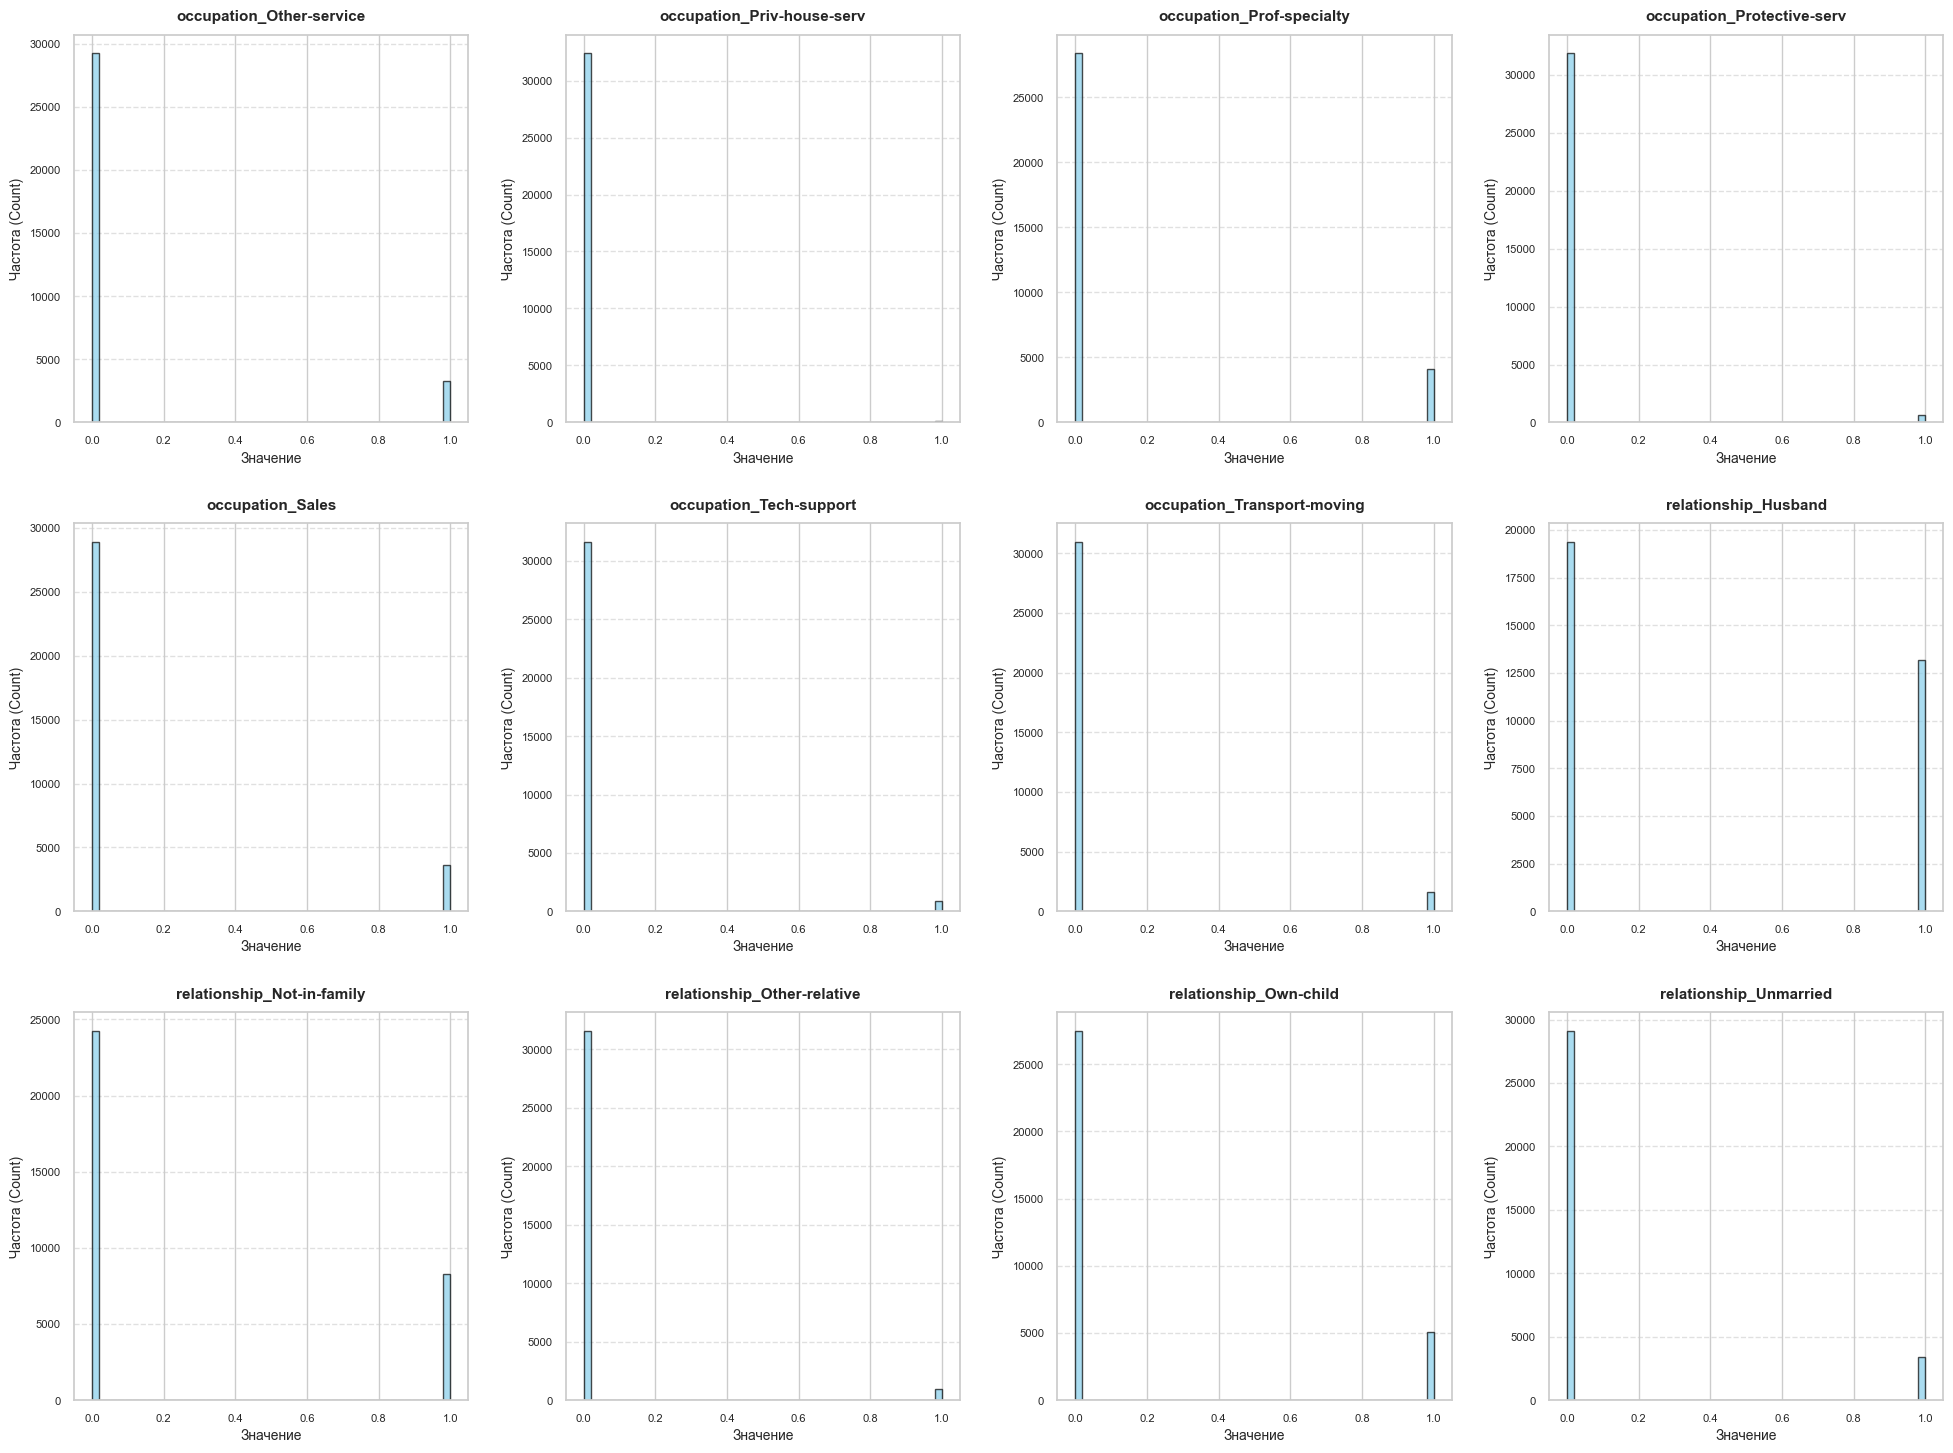

--- Отображена фигура 3 из 5 ---



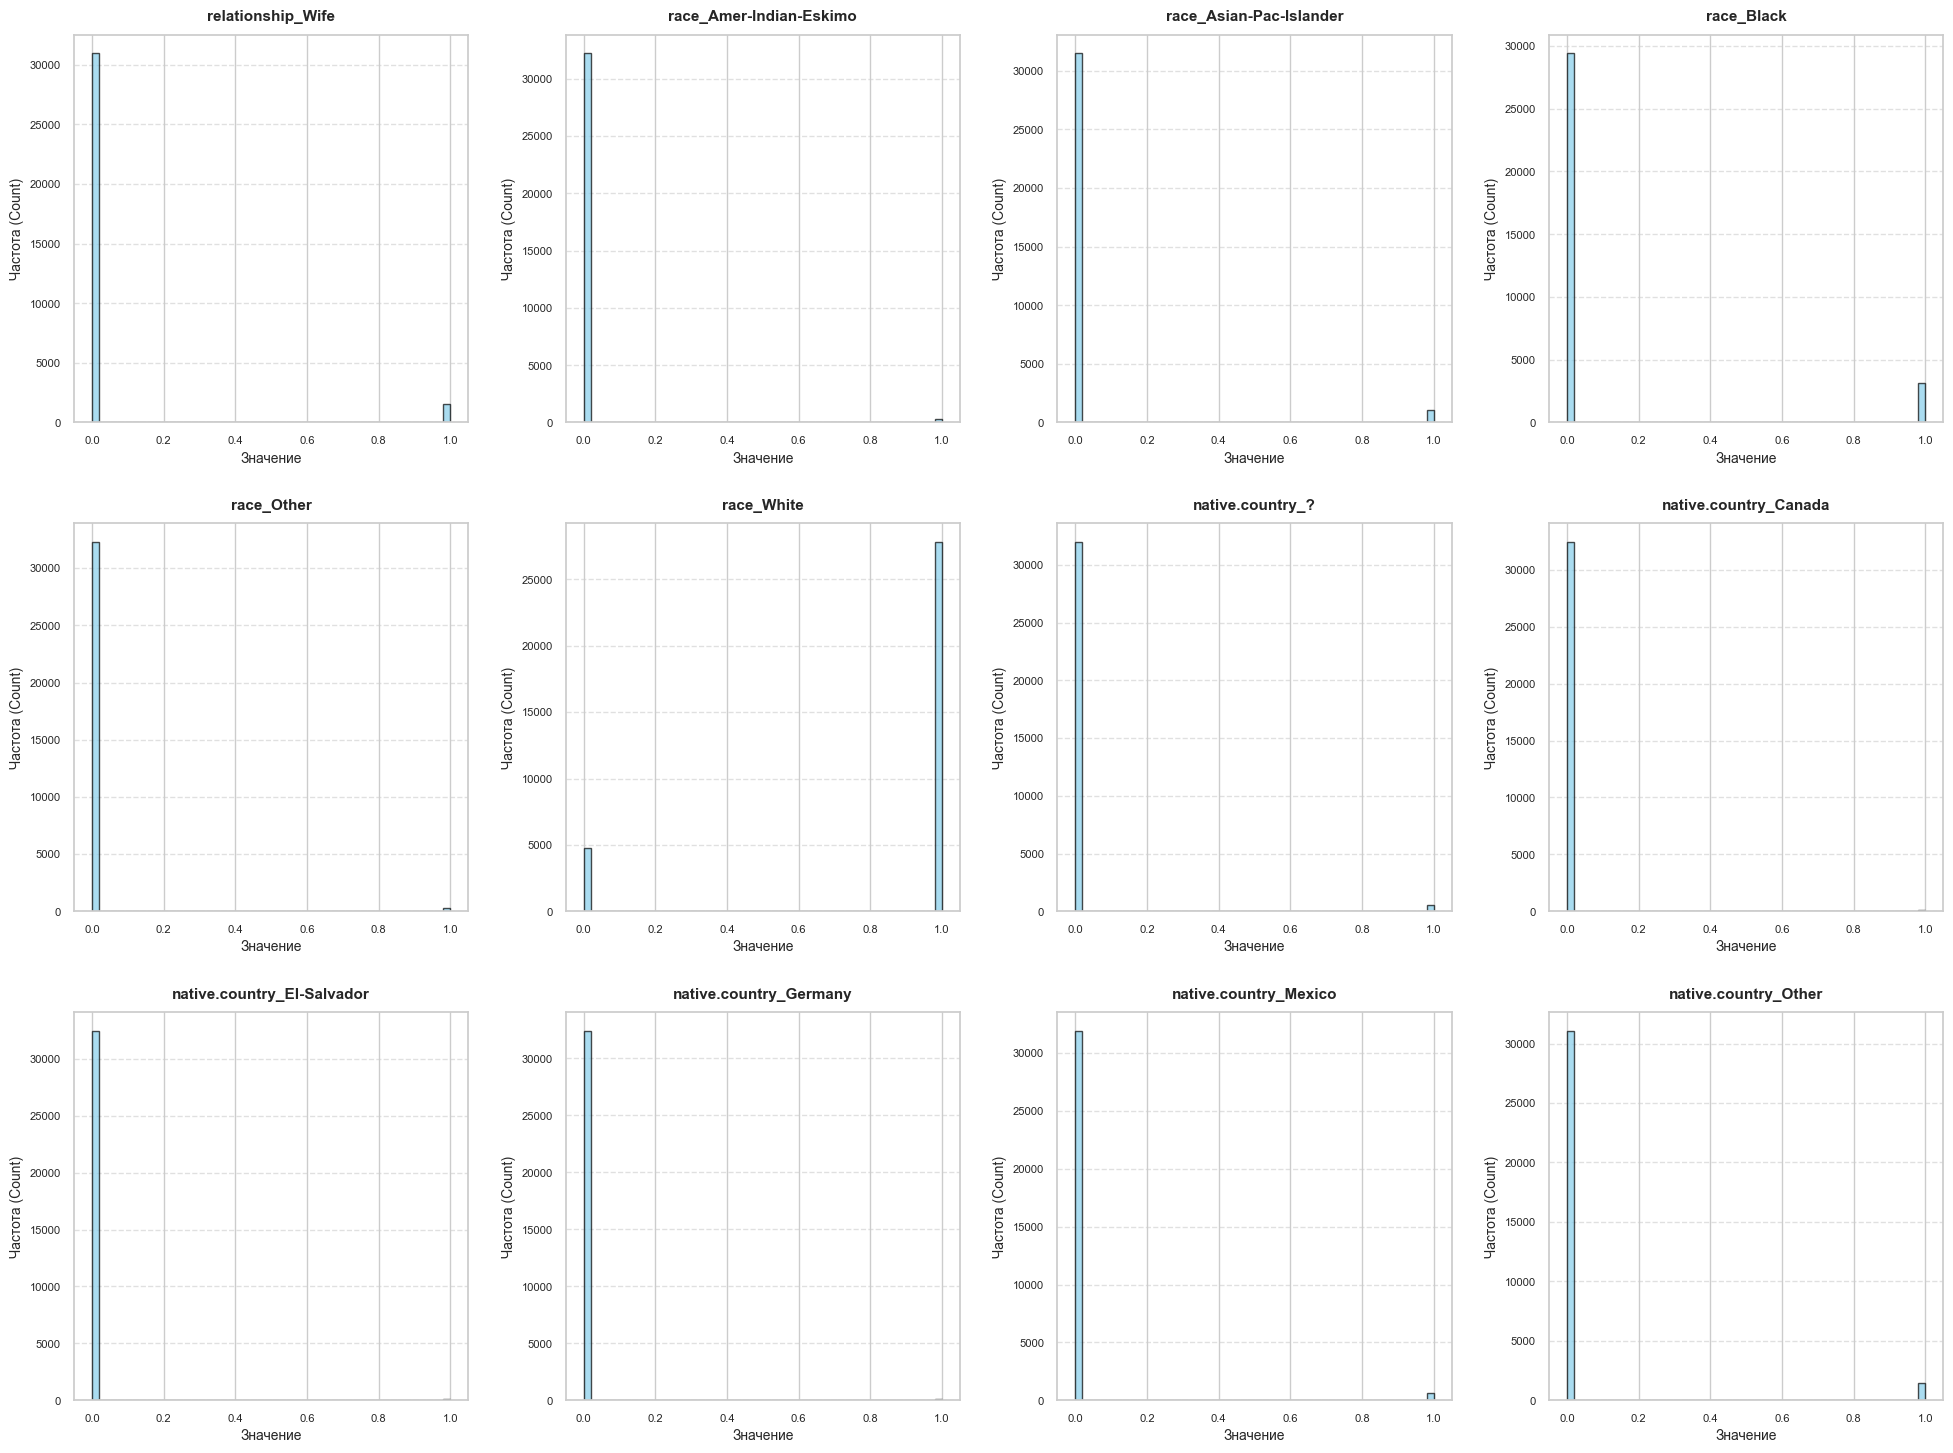

--- Отображена фигура 4 из 5 ---



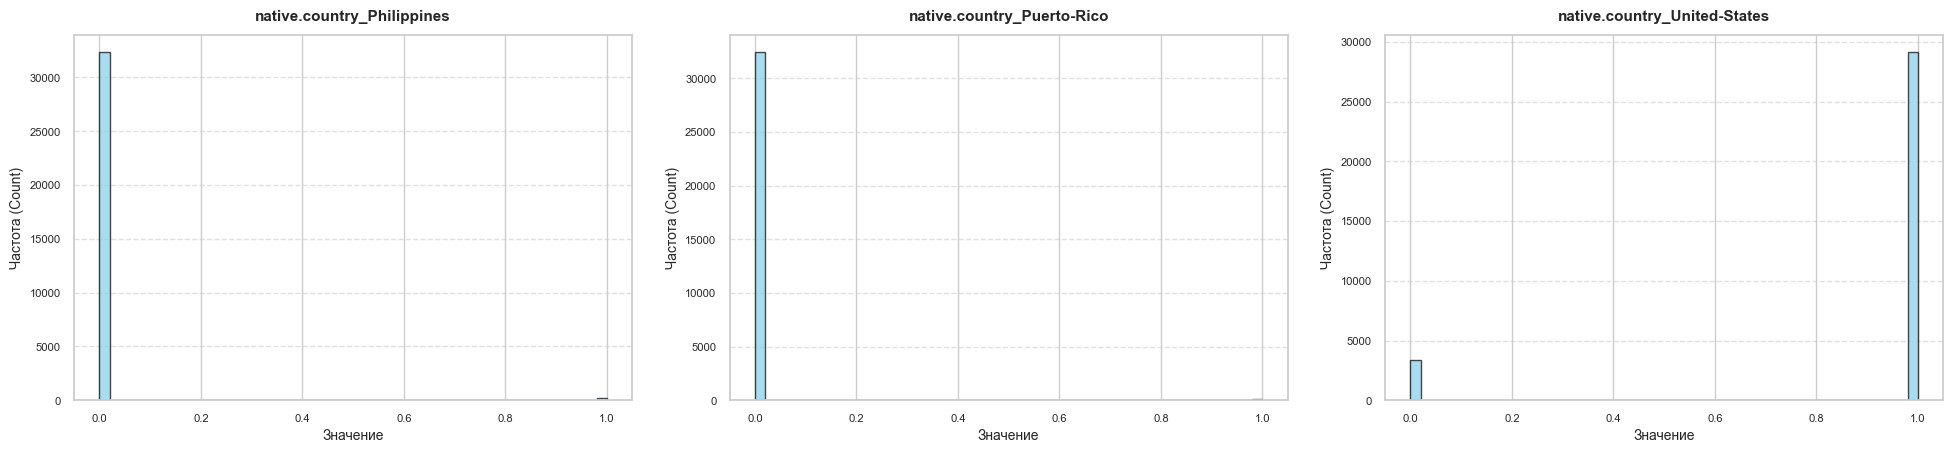

--- Отображена фигура 5 из 5 ---



In [70]:
def plot_numerical_with_missing(df, charts_per_figure=12, bins=30):
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    if not num_cols:
        print("Числовые колонки не найдены.")
        return

    print(f"Найдено числовых колонок: {len(num_cols)}. Начинаем построение...\n")

    chunks = [num_cols[i:i + charts_per_figure] for i in range(0, len(num_cols), charts_per_figure)]
    
    sns.set_theme(style="whitegrid", context="notebook")

    for chunk_idx, cols_chunk in enumerate(chunks):
        n_plots = len(cols_chunk)
        n_cols = 4 if n_plots >= 4 else n_plots
        n_rows = (n_plots + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
        if n_plots == 1:
            axes = [axes]
        else:
            axes = axes.flatten()
            

        for i, col in enumerate(cols_chunk):
            try:
                clean_data = df[col].dropna()

                color = "skyblue"

                axes[i].hist(clean_data, bins=bins, color=color, edgecolor='black', alpha=0.7)
                
                axes[i].set_ylabel("Частота (Count)", fontsize=10)
                axes[i].set_xlabel("Значение", fontsize=10)
                axes[i].grid(True, axis='y', linestyle='--', alpha=0.6)
                axes[i].tick_params(labelsize=8)
                
                title_text = f"{col}"
                axes[i].set_title(title_text, fontsize=11, pad=10, fontweight='bold')
                
                if len(clean_data) == 0:
                    axes[i].text(0.5, 0.5, "Нет данных для отображения", 
                                 transform=axes[i].transAxes, ha='center', va='center', color='red')
                
            except Exception as e:
                axes[i].text(0.5, 0.5, f"Ошибка:\n{str(e)}", transform=axes[i].transAxes, 
                             ha='center', va='center', color='red', fontsize=9, bbox=dict(facecolor='white', alpha=0.8))
                axes[i].set_title(f"{col} (Error)", fontsize=10, color='red')
                axes[i].axis('off')

        for j in range(n_plots, len(axes)):
            fig.delaxes(axes[j])
            
        plt.tight_layout(pad=2.0)
        plt.show()
        print(f"--- Отображена фигура {chunk_idx + 1} из {len(chunks)} ---\n")

plot_numerical_with_missing(data, charts_per_figure=12, bins=50)


In [71]:
class MLPClassifier(nn.Module):
    def __init__(self, input_size, hidden_sizes=[64, 32, 16], dropout_rate=0.3):
        super(MLPClassifier, self).__init__()
        layers = []
        prev_size = input_size
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size

        layers.append(nn.Linear(prev_size, 1)) # 1 это зависит от классов сколько вариантов ответов  столько и ставиться 
        layers.append(nn.Sigmoid())

        self.networks = nn.Sequential(*layers)

    def forward(self, x):
        return self.networks(x)
    

# Sigmoid
# nn.Sigmoid()
# 0 → 1
# Бинарная классификация (Да/Нет)
# Softmax
# nn.Softmax(dim=1)
# 0 → 1 (сумма = 1)
# Многоклассовая (Кошка/Собака/Птица)
# Linear
# nn.Identity() или нет функции
# -∞ → +∞
# Регрессия (Цена, возраст, сумма)
# Tanh
# nn.Tanh()
# -1 → +1
# Редко (специфичные задачи)


In [72]:
from torch.utils.data import DataLoader, TensorDataset
batch_size = 64
X_train_tensor = tch.FloatTensor(X_train)
y_train_tensor = tch.FloatTensor(y_train.values).reshape(-1, 1)

X_test_tensor = tch.FloatTensor(X_test)
y_test_tensor = tch.FloatTensor(y_test.values).reshape(-1, 1)

# 3. Создаём DataLoader (удобная загрузка данными маленькими порциями)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print(f"Размер батча: {batch_size}")

Размер батча: 64


In [73]:
import torch.optim as optim

# 1. Создаём модель
model = MLPClassifier(input_size=X_train.shape[1])

# 2. Функция потерь (как модель понимает, что ошиблась)
criterion = nn.BCELoss()

# Бинарная классификация (Да/Нет)
# # 1 нейрон + Sigmoid
# # BCELoss
# # nn.BCELoss()
# Бинарная классификация (альтернатива)
# # 2 нейрона + Softmax
# # CrossEntropyLoss
# # nn.CrossEntropyLoss()
# Многоклассовая (3+ класса)
# # N нейронов + Softmax
# # CrossEntropyLoss
# # nn.CrossEntropyLoss()
# Регрессия (число)
# 1 нейрон (без активации)
# # MSELoss
# # nn.MSELoss()
# Регрессия (устойчивая к выбросам)
# # 1 нейрон (без активации)
# # L1Loss
# # nn.L1Loss()


# 3. Оптимизатор (как модель исправляет ошибки)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# # SGD
# torch.optim.SGD
# Классика, но медленно
# Простой, предсказуемый
# # Adam
# torch.optim.Adam
# По умолчанию для большинства задач
# Быстрый, умный, работает из коробки
# # AdamW
# torch.optim.AdamW
# Когда есть риск переобучения
# Adam + регуляризация
# # RMSprop
# torch.optim.RMSprop
# Для RNN (рекуррентных сетей)

# Хорош для последовательностей
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)




print("Модель готова к обучению!")
print(model)

Модель готова к обучению!
MLPClassifier(
  (networks): Sequential(
    (0): Linear(in_features=50, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=16, out_features=1, bias=True)
    (13): Sigmoid()
  )
)


In [74]:
train_losses = []
model.train()
num_epochs = 50

In [75]:
best_loss = float('inf')
patience = 5
no_improve = 0

for epoch in range(num_epochs):
        epoch_loss = 0
        correct = 0
        total = 0
        # if avg_loss < best_loss - 0.001:  # Улучшение есть
        #     best_loss = avg_loss
        #     no_improve = 0
        # else:
        #     no_improve += 1
        
        # if no_improve >= patience:
        #     print(f"🛑 Early Stop на эпохе {epoch+1}")
        #     break
        
        for batch_X, batch_y in train_loader:
        # ─────────────────────────────────────
        # 1. Обнуляем старые градиенты
        # ─────────────────────────────────────    
            optimizer.zero_grad()
        # ─────────────────────────────────────
        # 2. FORWARD (Прямой проход)
        # ─────────────────────────────────────
            outputs = model(batch_X)
        # ─────────────────────────────────────
        # 2. Считаем ошибку (Loss)
        # ─────────────────────────────────────
            loss = criterion(outputs, batch_y)
        # ─────────────────────────────────────
        # 4. BACKWARD (Обратный проход) ⚠️
        # ─────────────────────────────────────
            loss.backward()
        # ─────────────────────────────────────
        # 5. STEP (Исправляем веса)
        # ─────────────────────────────────────
            optimizer.step()
        # ─────────────────────────────────────
        # 6. Считаем метрики для отчёта
        # ─────────────────────────────────────
            
            epoch_loss += loss.item()
            
            # ✅ Добавил подсчёт точности
            predicted_classes = (outputs >= 0.5).float()
            correct += (predicted_classes == batch_y).sum().item()
            total += batch_y.size(0)

        scheduler.step()
        avg_loss = epoch_loss / len(train_loader)
        accuracy = correct / total
        train_losses.append(avg_loss)

        # ✅ Выводим и Loss, и Accuracy
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}: Loss = {avg_loss:.4f} | Accuracy = {accuracy:.4f}')


Epoch 10: Loss = 0.3285 | Accuracy = 0.8471
Epoch 20: Loss = 0.3210 | Accuracy = 0.8485
Epoch 30: Loss = 0.3182 | Accuracy = 0.8511
Epoch 40: Loss = 0.3153 | Accuracy = 0.8531
Epoch 50: Loss = 0.3121 | Accuracy = 0.8548


In [76]:
from sklearn.metrics import accuracy_score, roc_auc_score

# === 1. Оценка на тренировочных данных ===
model.eval()
with tch.no_grad():
    # Train
    train_pred = model(X_train_tensor)
    train_proba = train_pred.numpy().flatten()
    train_classes = (train_pred >= 0.5).float().numpy().flatten()
    
    train_acc = accuracy_score(y_train, train_classes)
    train_auc = roc_auc_score(y_train, train_proba)
    
    # Test
    test_pred = model(X_test_tensor)
    test_proba = test_pred.numpy().flatten()
    test_classes = (test_pred >= 0.5).float().numpy().flatten()
    
    test_acc = accuracy_score(y_test, test_classes)
    test_auc = roc_auc_score(y_test, test_proba)

# === 2. Печатаем сравнение ===
print("📊 Сравнение метрик:")
print(f"{'Метрика':<12} {'Train':>10} {'Test':>10} {'Разница':>10}")
print("-" * 45)
print(f"{'Accuracy':<12} {train_acc:>10.4f} {test_acc:>10.4f} {abs(train_acc-test_acc):>10.4f}")
print(f"{'ROC-AUC':<12} {train_auc:>10.4f} {test_auc:>10.4f} {abs(train_auc-test_auc):>10.4f}")

    #Тестовая точность: 0.8515
#64, 32, 16
# 📊 Сравнение метрик:
# Метрика           Train       Test    Разница
# ---------------------------------------------
# Accuracy         0.8642     0.8515     0.0126
# ROC-AUC          0.9245     0.9072     0.0173

#4 слоя 128 64 32 16
# 📊 Сравнение метрик:
# Метрика           Train       Test    Разница
# ---------------------------------------------
# Accuracy         0.8640     0.8517     0.0123
# ROC-AUC          0.9246     0.9065     0.0181


📊 Сравнение метрик:
Метрика           Train       Test    Разница
---------------------------------------------
Accuracy         0.8639     0.8526     0.0113
ROC-AUC          0.9241     0.9072     0.0168


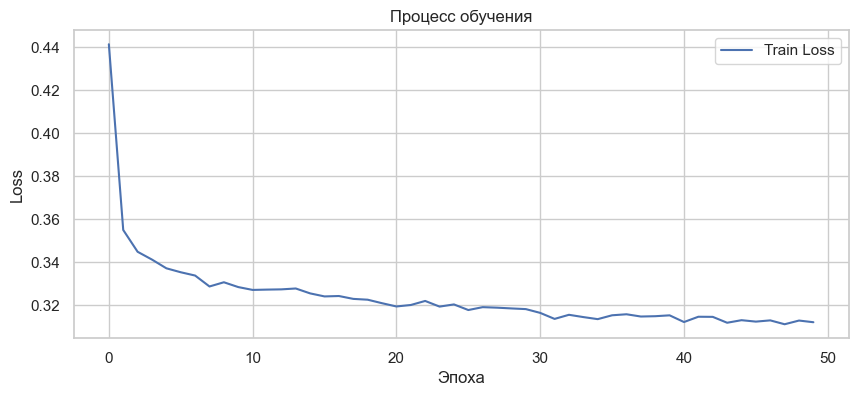

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Процесс обучения')
plt.grid(True)
plt.legend()
plt.show()

In [78]:
print(model)

MLPClassifier(
  (networks): Sequential(
    (0): Linear(in_features=50, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=16, out_features=1, bias=True)
    (13): Sigmoid()
  )
)


In [79]:
# Сохрани веса модели
tch.save(model.state_dict(), 'adult_pretrained.pth')
print("✅ Модель сохранена!")

✅ Модель сохранена!


In [ ]:
# # 2. Загружаем предобученные веса (если размеры совпадают)
# state_dict = tch.load('adult_pretrained.pth')
# model_dict = model_transfer.state_dict()

# # 3. Замораживаем первые слои
# def freeze_layers(model, num_layers_to_freeze):
#     """Замораживает первые num_layers_to_freeze слоёв"""
#     frozen = 0
#     total = 0
#     for i, (name, param) in enumerate(model.named_parameters()):
#         total += 1
#         if i < num_layers_to_freeze:
#             param.requires_grad = False
#             frozen += 1
#             print(f"🔒 Заморожен: {name}")
#         else:
#             print(f"🔓 Разморожен: {name}")
#     print(f"\nЗаморожено {frozen}/{total} параметров")
#     return frozen, total

# # Замораживаем первые 6 параметров (первые 2 линейных слоя + BatchNorm)
# frozen, total = freeze_layers(model_transfer, num_layers_to_freeze=6)

# # 4. Обучаем с меньшим learning rate
# optimizer_transfer = optim.Adam(
#     filter(lambda p: p.requires_grad, model_transfer.parameters()),
#     lr=0.0001  # В 10 раз меньше!
# )
# scheduler_transfer = optim.lr_scheduler.StepLR(optimizer_transfer, step_size=20, gamma=0.5)

# transfer_losses = []
# model_transfer.train()
# num_epochs = 100

# for epoch in range(num_epochs):
#     epoch_loss = 0
#     correct = 0
#     total = 0
    
#     for batch_X, batch_y in bank_train_loader:
#         optimizer_transfer.zero_grad()
#         outputs = model_transfer(batch_X)
#         loss = criterion(outputs, batch_y)
#         loss.backward()
#         optimizer_transfer.step()
        
#         epoch_loss += loss.item()
#         predicted_classes = (outputs >= 0.5).float()
#         correct += (predicted_classes == batch_y).sum().item()
#         total += batch_y.size(0)
    
#     scheduler_transfer.step()
#     avg_loss = epoch_loss / len(bank_train_loader)
#     accuracy = correct / total
#     transfer_losses.append(avg_loss)
    
#     if (epoch + 1) % 10 == 0:
#         print(f'Epoch {epoch+1}: Loss = {avg_loss:.4f} | Accuracy = {accuracy:.4f}')

# # 5. Оценка на тесте
# model_transfer.eval()
# with tch.no_grad():
#     transfer_pred = model_transfer(X_bank_test_tensor)
#     transfer_proba = transfer_pred.numpy().flatten()
#     transfer_classes = (transfer_pred >= 0.5).float().numpy().flatten()

# transfer_acc = accuracy_score(y_bank_test, transfer_classes)
# transfer_auc = roc_auc_score(y_bank_test, transfer_proba)

# print(f"\n📊 Transfer Learning результаты:")
# print(f"   Accuracy: {transfer_acc:.4f}")
# print(f"   ROC-AUC:  {transfer_auc:.4f}")


# ЭТОТ КОД НУЖЕН ЧТОБЫ ЗАМОРАЖИВАТЬ ВЕСА ОТДЕЛЬНО 